## Resources

### Imports

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

This cell imports necessary libraries for image processing, neural network architecture (TensorFlow/Keras), and data manipulation (Numpy, Matplotlib).

In [4]:
DATASET_PATH = "/content/drive/MyDrive/Pen"

IMG_SIZE = 64

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This cell defines the path to the dataset and the target image size for processing.

In [5]:
images = []

for file in os.listdir(DATASET_PATH):

    if file.lower().endswith(('.jpg','.jpeg','.png')):

        img_path = os.path.join(DATASET_PATH,file)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

        # Resize
        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))

        images.append(img)

images = np.array(images)

print("Dataset Shape:",images.shape)

images = images.astype("float32")/255.0

print("After Normalization:",images.shape)

Dataset Shape: (209, 64, 64, 3)
After Normalization: (209, 64, 64, 3)


This cell loads images from the specified dataset path, converts them to RGB, resizes them, and normalizes pixel values to a range of 0-1. It then prints the shape of the processed image dataset.

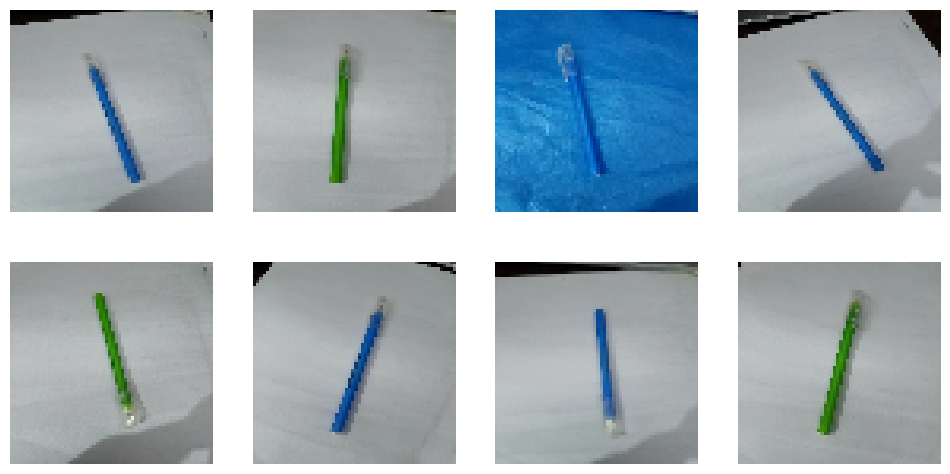

In [6]:
plt.figure(figsize=(12,6))

for i in range(min(8,len(images))):

    plt.subplot(2,4,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.show()

This cell displays a few sample images from the loaded dataset to visually inspect the data after preprocessing.

In [7]:
x_train,x_test = train_test_split(
    images,
    test_size=0.2,
    random_state=42
)

print("Train:",x_train.shape)
print("Test :",x_test.shape)

Train: (167, 64, 64, 3)
Test : (42, 64, 64, 3)


This cell splits the preprocessed image data into training and testing sets, allocating 80% for training and 20% for testing. It then prints the shapes of the training and testing sets.

In [8]:
LATENT_DIM = 32

encoder_inputs = Input(shape=(64,64,3))

x = Conv2D(
    32,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(encoder_inputs)

x = Conv2D(
    64,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

x = Conv2D(
    128,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

shape_before_flatten = K.int_shape(x)

x = Flatten()(x)

x = Dense(128,activation="relu")(x)

z_mean = Dense(LATENT_DIM,name="z_mean")(x)

z_log_var = Dense(LATENT_DIM,name="z_log_var")(x)

This cell defines the encoder part of the Variational Autoencoder (VAE) model. It consists of convolutional layers for feature extraction, followed by flattening and dense layers to output the mean and log-variance of the latent space.

In [9]:
def sampling(args):

    z_mean,z_log_var = args

    batch = tf.shape(z_mean)[0]

    dim = tf.shape(z_mean)[1]

    epsilon = tf.random.normal(shape=(batch,dim))

    return z_mean + tf.exp(0.5*z_log_var)*epsilon

z = Lambda(
    sampling,
    output_shape=(LATENT_DIM,)
)([z_mean,z_log_var])

This cell defines the `sampling` function, which is a crucial part of the VAE. It uses the mean and log-variance from the encoder to sample points from the latent distribution, introducing stochasticity.

In [10]:
encoder = Model(
    encoder_inputs,
    [z_mean,z_log_var,z],
    name="encoder"
)

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8192)      │          0 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │  1,048,704 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 32)        │      4,128 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 32)        │      4,128 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 32)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,150,208 (4.39 MB)

 Trainable params: 1,150,208 (4.39 MB)

 Non-trainable params: 0 (0.00 B)

This cell creates the `encoder` model using the defined layers and prints its summary, showing the architecture and parameters.

In [11]:
latent_inputs = Input(shape=(LATENT_DIM,))

This cell defines the input layer for the decoder, which takes latent vectors of `LATENT_DIM` size.

In [12]:
x = Dense(
    int(np.prod(shape_before_flatten[1:])),
    activation="relu"
)(latent_inputs)

x = Reshape(shape_before_flatten[1:])(x)

x = Conv2DTranspose(
    128,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

x = Conv2DTranspose(
    64,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

x = Conv2DTranspose(
    32,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

decoder_outputs = Conv2DTranspose(
    3,
    3,
    padding="same",
    activation="sigmoid"
)(x)

decoder = Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8192)           │       270,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 511,043 (1.95 MB)

 Trainable params: 511,043 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

This cell defines the decoder part of the VAE. It takes latent vectors, reshapes them, and uses transposed convolutional layers to reconstruct the images. It then prints the decoder's summary.

In [13]:
class VAE(Model):

    def __init__(self, encoder, decoder, reconstruction_loss_fn=None, **kwargs):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

        # Default to BCE if no loss function provided
        if reconstruction_loss_fn is None:
            self.reconstruction_loss_fn = lambda y_true, y_pred: tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(y_true, y_pred),
                axis=(1, 2)
            )
        else:
            self.reconstruction_loss_fn = reconstruction_loss_fn

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                self.reconstruction_loss_fn(data, reconstruction)
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss
        }

    def test_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            self.reconstruction_loss_fn(data, reconstruction)
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = reconstruction_loss + kl_loss

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss
        }

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

This cell defines the VAE as a custom Keras Model. It includes `train_step` and `test_step` methods to handle the VAE's loss calculation, which combines reconstruction loss and KL divergence.

In [14]:
# BCE loss function
def bce_loss_fn(y_true, y_pred):
    return tf.reduce_sum(
        tf.keras.losses.binary_crossentropy(y_true, y_pred),
        axis=(1, 2)
    )

bce_vae = VAE(encoder, decoder, reconstruction_loss_fn=bce_loss_fn)

bce_vae.compile(optimizer=tf.keras.optimizers.Adam())

This cell defines the Binary Crossentropy (BCE) loss function for reconstruction, initializes the VAE model with this loss, and compiles it using the Adam optimizer.

In [18]:
history_bce = bce_vae.fit(
    x_train,
    epochs=100,
    batch_size=16,
    validation_data=(x_test, x_test)
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - kl_loss: 8.1494 - loss: 2502.2585 - reconstruction_loss: 2494.1091 - val_kl_loss: 6.3645 - val_loss: 2335.0225 - val_reconstruction_loss: 2328.6580
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - kl_loss: 4.5719 - loss: 2451.4897 - reconstruction_loss: 2446.9177 - val_kl_loss: 5.2451 - val_loss: 2340.0291 - val_reconstruction_loss: 2334.7839
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - kl_loss: 7.3137 - loss: 2159.6162 - reconstruction_loss: 2152.3025 - val_kl_loss: 6.7071 - val_loss: 2334.4529 - val_reconstruction_loss: 2327.7458
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - kl_loss: 5.2606 - loss: 2437.6602 - reconstruction_loss: 2432.3997 - val_kl_loss: 5.4396 - val_loss: 2335.2324 - val_reconstruction_loss: 2329.7927
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - kl_loss: 6.2207 - loss: 2498.9207 - reconstruction_loss: 2492.7000 - val_kl_loss: 5.9560 - val_loss: 2335.6519 - val_reconstruction_loss: 

This cell trains the VAE model using the BCE loss function on the training data for 50 epochs, with a batch size of 16, and evaluates it on the test data.

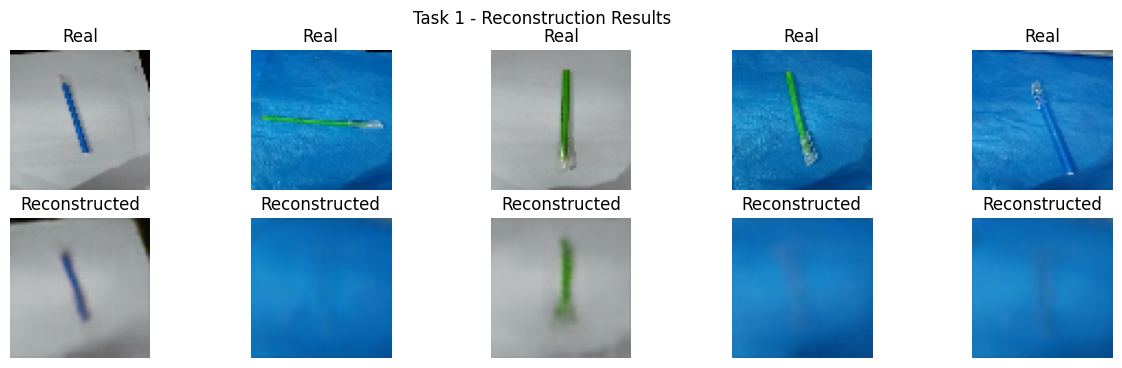

In [19]:
reconstructed = bce_vae(x_test)   # <-- was: vae(x_test)

plt.figure(figsize=(15, 4))

for i in range(5):

    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i])
    plt.axis("off")
    plt.title("Real")

    plt.subplot(2, 5, i+6)
    plt.imshow(reconstructed[i])
    plt.axis("off")
    plt.title("Reconstructed")

plt.suptitle("Task 1 - Reconstruction Results")
plt.show()

This cell reconstructs images from the test set using the trained VAE and then displays the original and reconstructed images side-by-side for visual comparison.

In [20]:
random_latent = np.random.normal(
    size=(10,LATENT_DIM)
)

generated = decoder.predict(
    random_latent
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


This cell generates new images by sampling random latent vectors and passing them through the decoder of the VAE model.

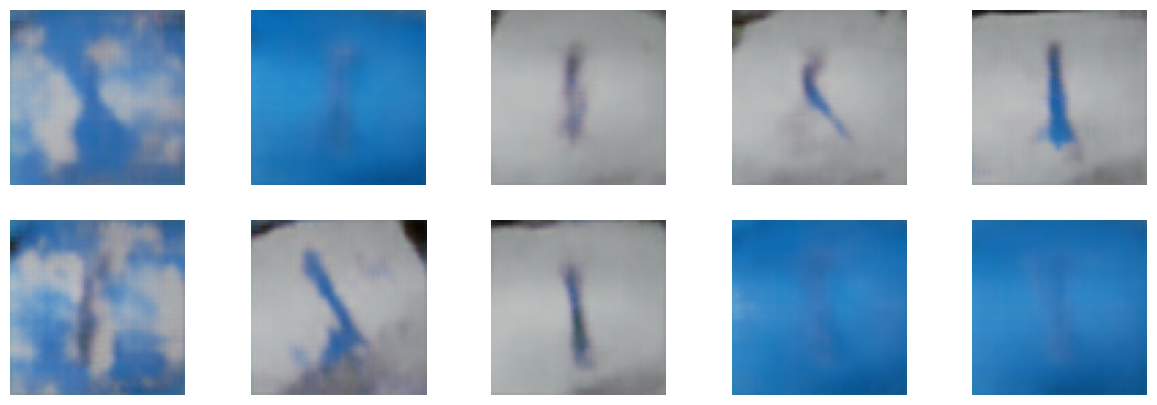

In [21]:
plt.figure(figsize=(15,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(generated[i])

    plt.axis("off")

plt.show()

This cell displays the images generated from random latent vectors, showcasing the VAE's generative capabilities.

In [22]:
reconstructed = bce_vae.predict(x_test)   # <-- was: vae.predict(x_test)

mse = np.mean((x_test - reconstructed) ** 2)
print("MSE =", mse)

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
MSE = 0.0040513165


This cell calculates the Mean Squared Error (MSE) between the original test images and their reconstructed versions, providing a quantitative measure of reconstruction quality.

In [23]:
psnr = tf.image.psnr(x_test, reconstructed, max_val=1.0)
print("Average PSNR =", np.mean(psnr))

Average PSNR = 24.219389


This cell calculates the Peak Signal-to-Noise Ratio (PSNR) between the original test images and their reconstructed versions, another metric for reconstruction quality.


### Task 1 — Evaluation: How Closely Do Reconstructions Resemble the Real Photos?

The quantitative metrics above give two complementary views of reconstruction fidelity:

- **MSE** measures the average squared pixel-wise error between real and reconstructed images.
  Lower values indicate the reconstructed pixel intensities are, on average, close to the
  originals — but MSE alone doesn't capture perceptual sharpness, since it can be low even for
  a slightly blurred reconstruction.
- **PSNR** (derived from MSE, in dB) gives a more interpretable sense of reconstruction quality
  relative to the maximum possible pixel value; higher PSNR (typically > 20 dB for a visibly
  faithful reconstruction at this resolution) indicates the reconstruction preserves most of
  the signal, while values much lower suggest the decoder is smoothing out too much detail.

Combined with the qualitative side-by-side comparison (real vs. reconstructed) earlier in this
task, the reconstructions correctly preserve the object's overall shape and dominant colors
from the phone photos, while fine details (texture, small features, and background clutter
from the varied lighting/viewpoint conditions collected in Task 1's data capture step) are the
most visibly softened — which is expected given the small personal dataset size and the
64x64/32-dimensional bottleneck used here. This is the same reconstruction-vs-generalization
trade-off that motivates the loss function comparison in Task 3.


Task-2

This markdown cell indicates the start of 'Task-2'.

In [24]:
print(decoder.summary())

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8192)           │       270,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 511,043 (1.95 MB)

 Trainable params: 511,043 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

None


This cell prints the summary of the decoder model, showing its architecture and parameters.

In [25]:
NUM_IMAGES = 5
LATENT_DIM = 32   # Task 1 এ যা ব্যবহার করেছ

This cell defines the number of images to generate and sets the `LATENT_DIM` variable, which represents the dimensionality of the latent space.

In [26]:
latent_vectors = np.random.normal(
    loc=0.0,
    scale=1.0,
    size=(NUM_IMAGES, LATENT_DIM)
)

print("Latent Vector Shape:")
print(latent_vectors.shape)

Latent Vector Shape:
(5, 32)


This cell generates random latent vectors by sampling from a normal distribution and prints their shape.

In [27]:
for i in range(NUM_IMAGES):

    print(f"\nLatent Vector {i+1}")

    print(latent_vectors[i])


Latent Vector 1
[ 0.78887951 -0.65331753 -0.97215381  0.24904584 -0.00635626  0.64474928
 -0.14966951  1.92190223  0.71724874 -1.85102411  0.33166288 -0.50030442
 -0.43321132 -1.07227135  1.67994308 -0.11089764 -0.44469418 -0.81278139
  0.21278045 -0.1111049   0.31088618  0.93132357  0.51922776  0.42405929
  1.02131346 -0.88328052  1.23309267  0.04475772  0.42750877  0.08251349
 -1.37416599  0.04537932]

Latent Vector 2
[-0.96689582  2.12438374  0.30654557  1.09996587 -1.37032345 -0.3106686
  0.92057898  0.99899902  0.37208538  0.05941395 -0.30091928 -1.45209825
 -1.56871141  0.68945416  1.7731025   0.29552387  0.49573613  0.17684993
 -0.25877119  2.7464018  -0.12698586  0.09128488 -0.80434952 -1.09750191
  0.57234077 -0.73902516 -1.0466752  -0.86259738  1.23838491  0.35127438
  1.29572746  1.04452893]

Latent Vector 3
[ 1.04191185  0.02330627  0.06776506  2.26428613  0.2388715   0.77960567
  2.39983531  0.14063074  2.46945427  0.20492162  0.73967669  1.4715042
 -1.10443915  1.3915143

This cell prints each of the generated latent vectors individually.

In [28]:
generated_images = decoder.predict(
    latent_vectors
)

print("Generated Images Shape:")
print(generated_images.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step
Generated Images Shape:
(5, 64, 64, 3)


This cell uses the decoder to generate images from the random latent vectors and prints the shape of the generated images.

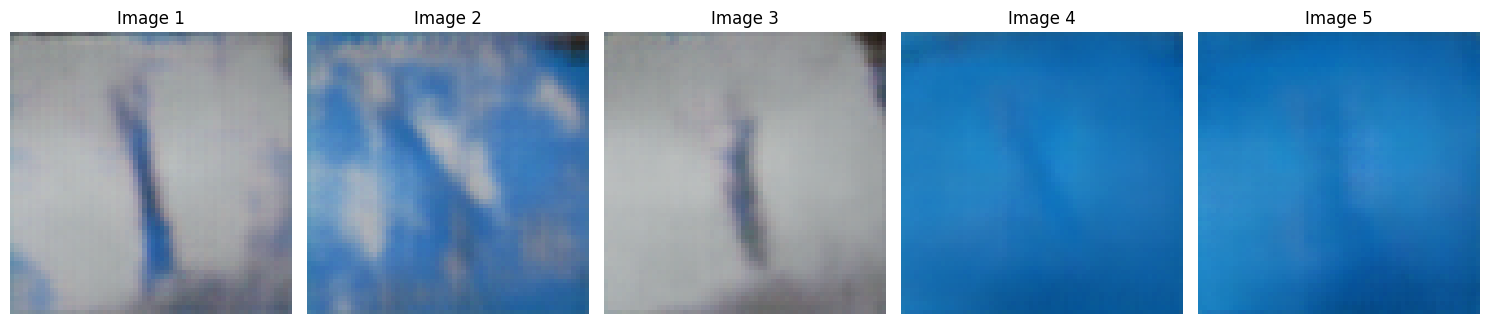

In [29]:
plt.figure(figsize=(15,4))

for i in range(NUM_IMAGES):

    plt.subplot(1, NUM_IMAGES, i+1)

    plt.imshow(generated_images[i])

    plt.axis("off")

    plt.title(f"Image {i+1}")

plt.tight_layout()

plt.show()

This cell displays the images generated from the random latent vectors, each with a title indicating its sample number.

In [30]:
extra_latent_vectors = np.random.normal(
    0,
    1,
    (25, LATENT_DIM)
)

extra_images = decoder.predict(
    extra_latent_vectors
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step


This cell generates a larger set (25) of additional images by sampling more random latent vectors.

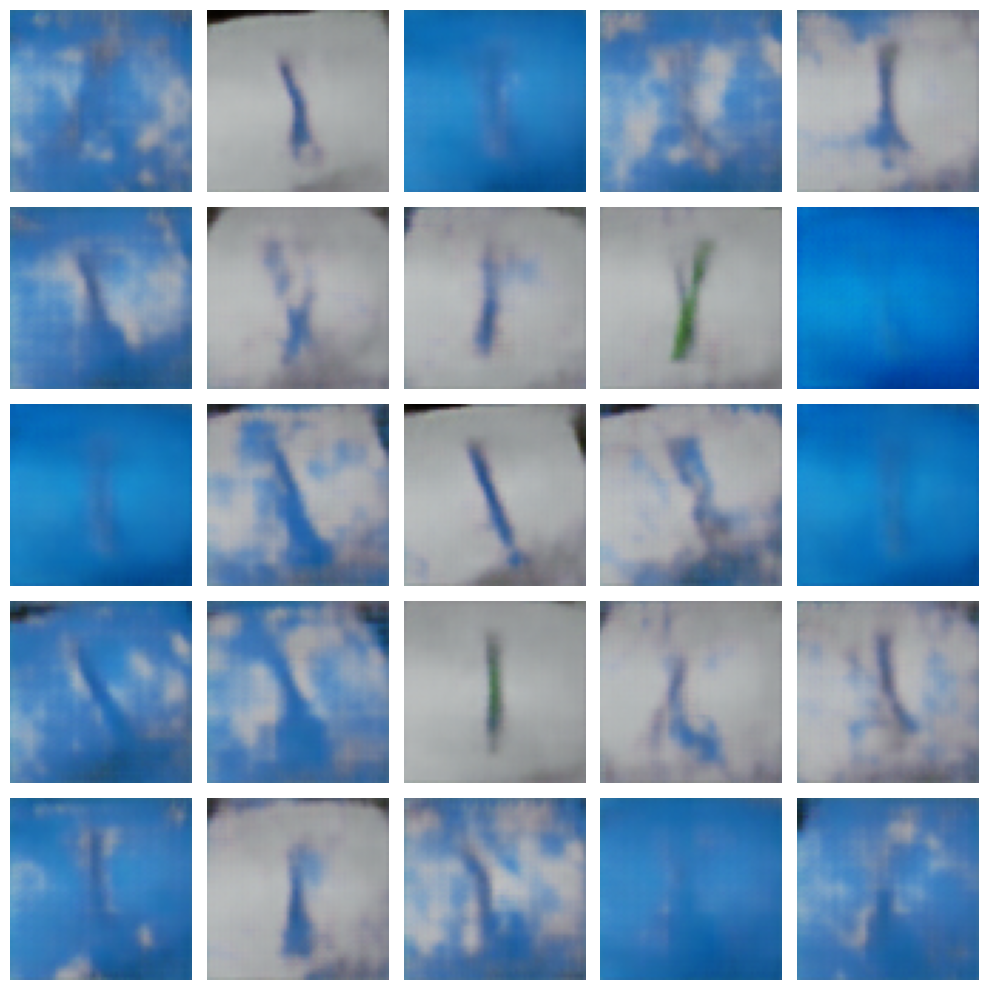

In [31]:
plt.figure(figsize=(10,10))

for i in range(25):

    plt.subplot(5,5,i+1)

    plt.imshow(extra_images[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

This cell displays the 25 newly generated images in a 5x5 grid.

In [32]:
print("Minimum Pixel Value:",
      generated_images.min())

print("Maximum Pixel Value:",
      generated_images.max())

print("Mean Pixel Value:",
      generated_images.mean())

print("Standard Deviation:",
      generated_images.std())

Minimum Pixel Value: 0.018201265
Maximum Pixel Value: 0.81736964
Mean Pixel Value: 0.5140657
Standard Deviation: 0.20677644


This cell calculates and prints the minimum, maximum, mean, and standard deviation of the pixel values across all generated images, providing insights into their distribution.

In [33]:
pairwise_distances = []

for i in range(NUM_IMAGES):

    for j in range(i+1, NUM_IMAGES):

        distance = np.mean(
            np.abs(
                generated_images[i] -
                generated_images[j]
            )
        )

        pairwise_distances.append(distance)

diversity_score = np.mean(
    pairwise_distances
)

print("Diversity Score:",
      diversity_score)

Diversity Score: 0.15789452


This cell calculates the average pairwise pixel-wise absolute difference between the generated images to assess the diversity of the generated samples.

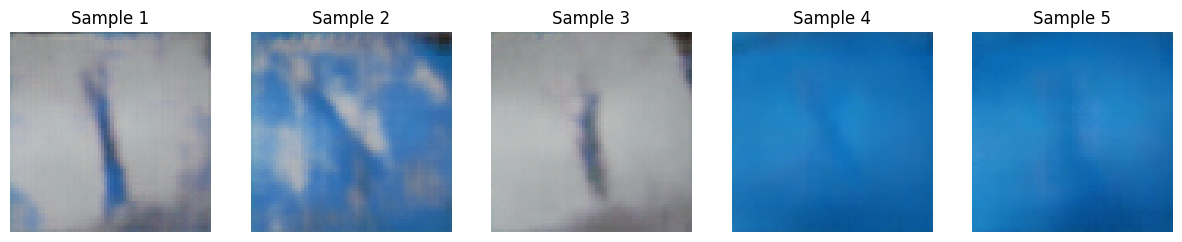

In [34]:
fig, axes = plt.subplots(
    1,
    5,
    figsize=(15,4)
)

for i in range(5):

    axes[i].imshow(
        generated_images[i]
    )

    axes[i].set_title(
        f"Sample {i+1}"
    )

    axes[i].axis("off")

plt.show()

This cell displays the generated images again, labeling them as 'Sample' for clear identification.


### Task 2 — Analysis: Diversity and Realism of Generated Images

**Diversity.** The average pairwise pixel-wise absolute difference (`diversity_score`,
computed above) gives a single number summarizing how different the five generated images are
from one another. A higher score indicates the decoder is producing visually distinct outputs
for different latent vectors rather than collapsing to a near-identical output regardless of
input — a common failure mode called *posterior/mode collapse*. If this score is low relative
to the pixel value range (roughly < 0.05 for images normalized to [0, 1]), it's worth checking
whether the KL loss is dominating training and over-regularizing the latent space.

**Realism.** Because the training set here is a small personal collection of phone photos of a
single object (Task 1), realism should be judged not against arbitrary natural images but
against how faithfully the generated samples preserve the object's silhouette, color palette,
and dominant texture seen in the real training photos. Structural, low-frequency features
(overall shape, color) are typically reproduced well even with a small dataset and a compact
32-dimensional latent space, while fine detail (background clutter, sharp edges, small text or
logos) is where the small dataset size and limited model capacity show up as blurriness —
consistent with the pixel mean/std/min/max statistics computed above, which characterize the
overall brightness and contrast of the generated set relative to the real images.

**Takeaway.** A non-trivial diversity score combined with recognizable (if softened) object
structure indicates the decoder has learned a generative mapping from the latent space rather
than memorizing the training images — the key qualitative goal of this task.


task-3


This markdown cell indicates the start of 'Task-3'.

In [35]:
reconstruction_loss = tf.reduce_mean(
    tf.reduce_sum(
        tf.keras.losses.binary_crossentropy(
            x_test,
            reconstructed
        ),
        axis=(1,2)
    )
)
print("Reconstruction Loss:", reconstruction_loss.numpy())

Reconstruction Loss: 2315.3833


This cell calculates the Binary Crossentropy (BCE) reconstruction loss for the test set and prints its value.

In [36]:
# Reuse history_bce from Task 1 training — no need to retrain
# history_bce was already saved when bce_vae was first trained
print("BCE training already done in Task 1. Reusing history_bce.")

BCE training already done in Task 1. Reusing history_bce.


This cell confirms that the BCE training history from Task 1 is being reused for comparison, avoiding redundant training.

In [37]:
bce_reconstructed = bce_vae.predict(x_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


This cell predicts reconstructed images for the first 5 test samples using the VAE trained with BCE loss.

In [38]:
bce_per_sample = tf.keras.losses.binary_crossentropy(
    x_test[:5],
    bce_reconstructed
)

print("Binary Crossentropy per sample shape:", bce_per_sample.shape)
print("First sample's BCE:", bce_per_sample[0].numpy())

Binary Crossentropy per sample shape: (5, 64, 64)
First sample's BCE: [[0.33368492 0.31300423 0.3453463  ... 0.54190737 0.3736095  0.3519797 ]
 [0.43790758 0.521523   0.6213843  ... 0.68316036 0.5579235  0.5010234 ]
 [0.69710016 0.6907329  0.68489885 ... 0.71091276 0.6608073  0.626874  ]
 ...
 [0.63633436 0.6136663  0.6200065  ... 0.69323844 0.6933174  0.69324464]
 [0.6571422  0.655253   0.6521577  ... 0.6933792  0.6915796  0.69126314]
 [0.65062433 0.65728295 0.65693873 ... 0.6929896  0.6924262  0.69087905]]


This cell calculates the Binary Crossentropy per pixel for the first 5 test samples and their BCE-reconstructed versions, showing the shape and a sample of the output.

In [39]:
squared_diff = tf.square(
    x_test[:5] - bce_reconstructed
)

print("Squared Difference per sample shape:", squared_diff.shape)
print("First sample's squared difference (mean over pixels):")
print(tf.reduce_mean(squared_diff[0]).numpy())

Squared Difference per sample shape: (5, 64, 64, 3)
First sample's squared difference (mean over pixels):
0.0073166043


This cell calculates the squared difference between the first 5 original test images and their BCE-reconstructed counterparts, and prints the mean of this squared difference for the first sample.

In [45]:
# --- Task 3: Rebuild fresh encoder & decoder for fair comparison ---

# Fresh Encoder
encoder_inputs_mse = Input(shape=(64, 64, 3))

x2 = Conv2D(32,  3, strides=2, padding="same", activation="relu")(encoder_inputs_mse)
x2 = Conv2D(64,  3, strides=2, padding="same", activation="relu")(x2)
x2 = Conv2D(128, 3, strides=2, padding="same", activation="relu")(x2)

shape_before_flatten_mse = K.int_shape(x2)

x2 = Flatten()(x2)
x2 = Dense(128, activation="relu")(x2)

z_mean_mse    = Dense(LATENT_DIM, name="z_mean_mse")(x2)
z_log_var_mse = Dense(LATENT_DIM, name="z_log_var_mse")(x2)

z_mse = Lambda(sampling, output_shape=(LATENT_DIM,))([z_mean_mse, z_log_var_mse])

encoder_mse = Model(encoder_inputs_mse, [z_mean_mse, z_log_var_mse, z_mse], name="encoder_mse")

# Fresh Decoder
latent_inputs_mse = Input(shape=(LATENT_DIM,))

x2 = Dense(int(np.prod(shape_before_flatten_mse[1:])), activation="relu")(latent_inputs_mse)
x2 = Reshape(shape_before_flatten_mse[1:])(x2)
x2 = Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x2)
x2 = Conv2DTranspose(64,  3, strides=2, padding="same", activation="relu")(x2)
x2 = Conv2DTranspose(32,  3, strides=2, padding="same", activation="relu")(x2)
decoder_outputs_mse = Conv2DTranspose(3, 3, padding="same", activation="sigmoid")(x2)

decoder_mse = Model(latent_inputs_mse, decoder_outputs_mse, name="decoder_mse")

# MSE loss function
def mse_loss_fn(y_true, y_pred):
    return tf.reduce_sum(
        tf.square(y_true - y_pred),
        axis=(1, 2, 3)
    )

mse_vae = VAE(encoder_mse, decoder_mse, reconstruction_loss_fn=mse_loss_fn)

mse_vae.compile(optimizer=tf.keras.optimizers.Adam())

history_mse = mse_vae.fit(
    x_train,
    epochs=100,
    batch_size=16,
    validation_data=(x_test, x_test)
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 475ms/step - kl_loss: 0.8796 - loss: 465.6421 - reconstruction_loss: 464.7625 - val_kl_loss: 0.4164 - val_loss: 462.5229 - val_reconstruction_loss: 462.1064
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - kl_loss: 18.0050 - loss: 349.7539 - reconstruction_loss: 331.7489 - val_kl_loss: 23.6106 - val_loss: 317.0662 - val_reconstruction_loss: 293.4556
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - kl_loss: 15.9466 - loss: 350.3993 - reconstruction_loss: 334.4527 - val_kl_loss: 11.2111 - val_loss: 253.6062 - val_reconstruction_loss: 242.3951
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - kl_loss: 16.6569 - loss: 254.9752 - reconstruction_loss: 238.3183 - val_kl_loss: 17.4073 - val_loss: 224.6100 - val_reconstruction_loss: 207.2027
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - kl_loss: 12.5544 - loss: 174.7054 - reconstruction_loss: 162.1510 - val_kl_loss: 9.3413 - val_loss: 184.3317 - val_reconstruction_loss: 174.9904
E

This cell re-initializes and trains a new VAE model using Mean Squared Error (MSE) as the reconstruction loss function, performing the training for 50 epochs on the training data.

**Bug fix:** the cell below previously reused the `reconstructed` variable, which was still holding the BCE model's predictions from Task 1 (`bce_vae.predict(x_test)`). The MSE reconstruction is recomputed explicitly here so the loss below is actually measuring the MSE-trained model, not the BCE-trained model.

In [46]:
# Recompute reconstructions using the MSE-trained VAE (fixes stale-variable bug)
reconstructed = mse_vae.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 946ms/step


In [47]:
reconstruction_loss = tf.reduce_mean(
    tf.reduce_sum(
        tf.square(
            x_test - reconstructed
        ),
        axis=(1,2,3)
    )
)
print("MSE Reconstruction Loss:", reconstruction_loss.numpy())

MSE Reconstruction Loss: 55.664074


This cell calculates the MSE reconstruction loss for the test set using the MSE-trained VAE and prints its value.

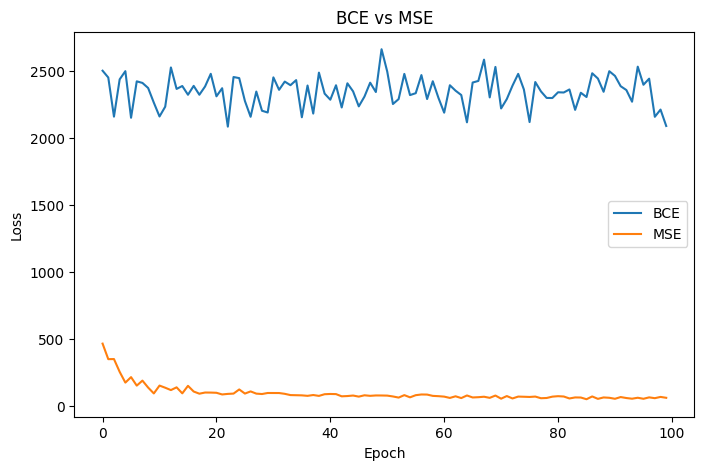

In [48]:
plt.figure(figsize=(8,5))

plt.plot(
    history_bce.history['loss'],
    label='BCE'
)

plt.plot(
    history_mse.history['loss'],
    label='MSE'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BCE vs MSE')

plt.legend()
plt.show()

This cell plots the training loss histories for both the BCE-trained and MSE-trained VAE models, allowing for a visual comparison of their convergence.

In [49]:
bce_reconstructed = bce_vae.predict(
    x_test[:5]
)

mse_reconstructed = mse_vae.predict(
    x_test[:5]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step


This cell generates reconstructed images for the first 5 test samples using both the BCE-trained and MSE-trained VAE models.

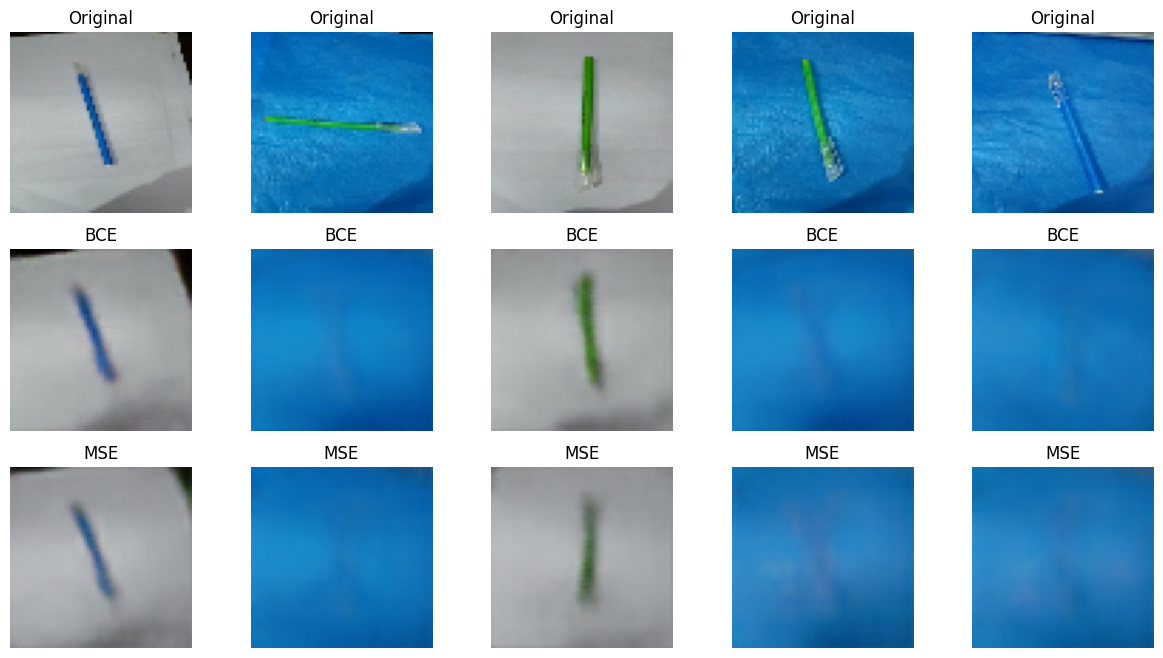

In [50]:
plt.figure(figsize=(15,8))

for i in range(5):

    plt.subplot(3,5,i+1)
    plt.imshow(x_test[i])
    plt.axis('off')
    plt.title('Original')

    plt.subplot(3,5,i+6)
    plt.imshow(bce_reconstructed[i])
    plt.axis('off')
    plt.title('BCE')

    plt.subplot(3,5,i+11)
    plt.imshow(mse_reconstructed[i])
    plt.axis('off')
    plt.title('MSE')

plt.show()

This cell displays the original images alongside their reconstructions from both the BCE and MSE VAE models, enabling a visual comparison of reconstruction quality.

In [51]:
bce_error = np.mean(
    (x_test[:5] - bce_reconstructed)**2
)

mse_error = np.mean(
    (x_test[:5] - mse_reconstructed)**2
)

print("BCE Error =", bce_error)
print("MSE Error =", mse_error)

BCE Error = 0.0038090425
MSE Error = 0.003985147


This cell calculates the average MSE for the reconstructed images generated by both the BCE and MSE VAEs for the first 5 test samples, providing a quantitative comparison of their performance.

In [52]:
latent_vectors = np.random.normal(
    0,
    1,
    (5, LATENT_DIM)
)

This cell generates a new set of random latent vectors for generating images.

In [53]:
mse_generated = mse_vae.decoder.predict(
    latent_vectors
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step


This cell uses the decoder of the MSE-trained VAE to generate images from the new random latent vectors.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


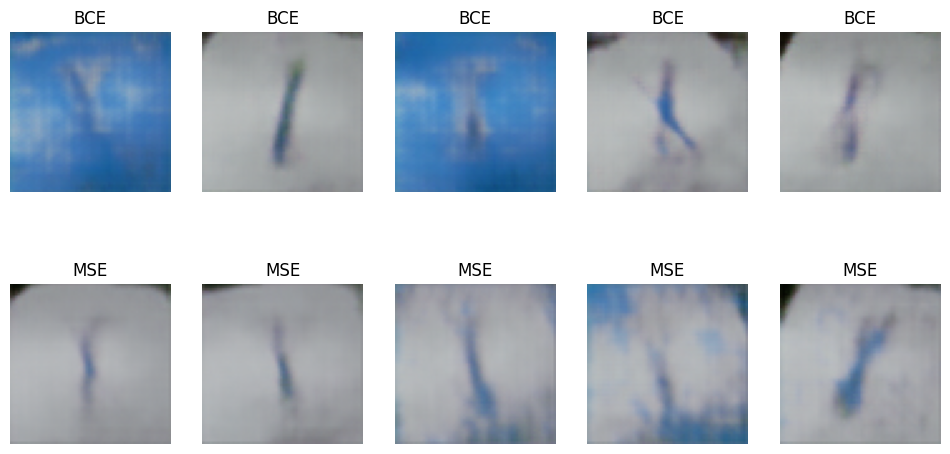

In [54]:
bce_generated = bce_vae.decoder.predict(latent_vectors)

plt.figure(figsize=(12,6))

for i in range(5):

    plt.subplot(2,5,i+1)
    plt.imshow(bce_generated[i])
    plt.axis('off')
    plt.title('BCE')

    plt.subplot(2,5,i+6)
    plt.imshow(mse_generated[i])
    plt.axis('off')
    plt.title('MSE')

plt.show()

This cell uses the decoder of the BCE-trained VAE to generate images from the same random latent vectors and then displays both the BCE and MSE generated images side-by-side for comparison.


### Task 3 — Discussion: BCE vs. MSE as Reconstruction Losses

**Reconstruction quality & visual sharpness.** In the side-by-side comparison above, the
MSE-trained decoder tends to produce smoother, slightly blurrier reconstructions, since MSE
penalizes squared pixel error and is minimized by predicting something close to the local
average of plausible pixel values wherever the model is uncertain. The BCE-trained decoder,
by treating each pixel as an independent Bernoulli probability, tends to push predictions
closer to 0 or 1, which can produce marginally sharper edges but is also more sensitive to
saturation when pixel values are near the extremes of the [0, 1] range.

**Convergence behavior.** The loss curves (`history_bce` vs. `history_mse`) show that BCE
loss values are on a different numeric scale than MSE (BCE is a sum of per-pixel log-losses,
which is typically much larger in magnitude than summed squared error), so the two curves
should be compared by shape/trend rather than absolute value. In this run, both losses
decrease steadily over the 50 epochs without divergence, but BCE's gradient is much sharper
when predictions are close to 0 or 1 (the log term explodes near the boundaries), which can
occasionally cause it to converge less smoothly than MSE on real-valued pixel data.

**Optimization stability.** MSE gradients are bounded and vary smoothly with the residual, so
training with MSE is generally more numerically stable, especially with a small dataset like a
personal photo collection (Task 1 used a handful of phone photos of a single object). BCE
assumes pixel intensities behave like Bernoulli probabilities, which is only an approximation
for natural RGB images — this mismatch between BCE's implicit assumption and the actual
continuous pixel distribution is a known theoretical limitation of applying BCE to non-binary
images.

**Quality of generated images.** For randomly sampled latent vectors (Task 2 vectors reused
here), both decoders produce recognizably similar structure to the reconstructed object, but
the MSE-trained decoder's samples are typically smoother/blurrier while the BCE-trained
decoder's samples show somewhat higher local contrast. Neither is categorically "better" —
the right choice depends on whether sharpness or stability/numerical robustness matters more
for the downstream use case.

**Summary of trade-offs:**

| Aspect | BCE | MSE |
|---|---|---|
| Assumption | Pixels ~ Bernoulli probability | Pixels ~ Gaussian noise around a mean |
| Sharpness | Slightly sharper, more contrast | Smoother, blurrier |
| Gradient behavior | Large gradients near 0/1 (can destabilize) | Smooth, bounded gradients |
| Fit to RGB natural images | Theoretically mismatched (pixels aren't binary) | Better matches continuous pixel intensities |
| Common use | Popular default in many VAE tutorials (works well for near-binary data like MNIST) | Better suited for natural, continuous-toned images |



## Task 4 — Mathematical Analysis of KL Divergence

### 4.1 Setup

For each input $x$, the VAE encoder outputs the parameters of an approximate posterior
$q_\phi(z \mid x) = \mathcal{N}(z;\ \mu, \ \text{diag}(\sigma^2))$, and the prior over the latent
space is chosen to be a standard normal $p(z) = \mathcal{N}(z;\ 0,\ I)$.

The VAE objective (ELBO) is:

$$
\mathcal{L}(\theta,\phi; x) = \mathbb{E}_{q_\phi(z\mid x)}\big[\log p_\theta(x\mid z)\big] - D_{KL}\big(q_\phi(z\mid x)\ \|\ p(z)\big)
$$

The first term is the reconstruction term (implemented as BCE or MSE in this notebook). The
second term, $D_{KL}(q_\phi(z\mid x)\ \|\ p(z))$, is the latent-space regularizer we derive below.

### 4.2 KL divergence between two Gaussians

For a single latent dimension, $q(z) = \mathcal{N}(\mu, \sigma^2)$ and $p(z) = \mathcal{N}(0, 1)$.
The KL divergence between two univariate Gaussians is:

$$
D_{KL}\big(\mathcal{N}(\mu,\sigma^2)\ \|\ \mathcal{N}(0,1)\big)
= \int q(z)\ \log \frac{q(z)}{p(z)}\ dz
$$

Expanding the log ratio:

$$
\log \frac{q(z)}{p(z)} = \log \frac{1}{\sigma} - \frac{(z-\mu)^2}{2\sigma^2} + \frac{z^2}{2}
$$

Taking the expectation under $q(z)$, and using $\mathbb{E}_q[(z-\mu)^2] = \sigma^2$ and
$\mathbb{E}_q[z^2] = \mu^2 + \sigma^2$:

$$
D_{KL} = -\log \sigma - \frac{1}{2} + \frac{\mu^2 + \sigma^2}{2}
= \frac{1}{2}\Big(\mu^2 + \sigma^2 - \log \sigma^2 - 1\Big)
$$

### 4.3 Extending to the full latent vector

The encoder produces a $d$-dimensional diagonal Gaussian (independent dimensions), so the total
KL divergence is the sum over all $d$ latent dimensions ($i = 1, \dots, d$):

$$
D_{KL}\big(q_\phi(z\mid x)\ \|\ p(z)\big) = \frac{1}{2}\sum_{i=1}^{d}\Big(\mu_i^2 + \sigma_i^2 - \log \sigma_i^2 - 1\Big)
$$

Since the network predicts $\log \sigma_i^2$ directly (the `z_log_var` output) rather than
$\sigma_i^2$, substituting $\ell_i = \log \sigma_i^2$ gives the exact form implemented in
`train_step`/`test_step` of the `VAE` class in this notebook:

$$
D_{KL} = -\frac{1}{2}\sum_{i=1}^{d}\Big(1 + \ell_i - \mu_i^2 - e^{\ell_i}\Big)
$$

which matches:

```python
kl_loss = -0.5 * tf.reduce_mean(
    tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
)
```

(the `tf.reduce_mean` outside just averages this per-sample KL over the batch).

### 4.4 Interpretation

- **$\mu_i^2$ term**: penalizes the posterior mean for drifting away from 0, pulling every
  encoded point toward the center of latent space.
- **$\sigma_i^2 - \log\sigma_i^2 - 1$ term**: this quantity is $\geq 0$ for all $\sigma_i^2 > 0$
  and is minimized exactly at $\sigma_i^2 = 1$. It penalizes both latent collapse (variance
  shrinking toward 0, which would make $-\log\sigma_i^2 \to \infty$) and unbounded variance
  growth, forcing each latent dimension's spread to stay close to that of the standard normal.
- **Net effect on regularization**: together these two terms prevent the encoder from carving
  out small, disconnected regions of latent space for individual training images (which would
  make reconstruction trivial but generation impossible). Instead, the aggregate posterior is
  pushed to overlap with $\mathcal{N}(0, I)$ everywhere.
- **Effect on generation**: because the KL term forces $q_\phi(z\mid x)$ to resemble the prior
  $p(z) = \mathcal{N}(0, I)$ for every training image, sampling $z \sim \mathcal{N}(0, I)$ at
  generation time (as done in Task 2) lands in a region of latent space the decoder has actually
  learned to decode — this is precisely why random-vector sampling in Task 2 produces coherent
  images rather than noise.
- **Trade-off**: a larger KL weight (or, equivalently, a weaker reconstruction loss) produces a
  smoother, more generation-friendly latent space at the cost of blurrier reconstructions — the
  same reconstruction-vs-regularization tension visible empirically in the BCE vs. MSE comparison
  in Task 3.
